# Multi-Physics Pipeline with End-to-End Gradient Optimization

In this tutorial, you will learn how to:

1. Build two independent physics Tesseracts from different domains -- a thermal solver and a structural solver.
2. Compose them into a two-way coupled pipeline with Tesseract-JAX, where each solver feeds back into the other.
3. Compute end-to-end gradients through the coupled iteration with `jax.grad`, and validate them against finite differences.
4. Perform gradient-based optimization of a thermoelastic inverse-design problem using `scipy.optimize`.
5. Switch to implicit differentiation for constant-memory gradients via the implicit function theorem.

## Context

Many engineering systems are *multi-physics*: their behaviour emerges from the interaction of several physical processes, each usually modelled by its own specialized solver. A classic example is *thermoelasticity* -- a temperature field makes a material expand, the resulting deformation changes the geometry, and the changed geometry in turn changes how heat flows. Neither solver is correct on its own; the answer lives in the coupling between them.

Designing such systems means solving inverse problems through the coupled physics: *what inputs produce the behaviour we want, once everything has settled into equilibrium?* Answering that efficiently requires gradients through the full coupled chain. Traditionally this means either a fragile hand-coded adjoint or rewriting every solver into one monolithic codebase.

Tesseracts offer a different path, and that is what this demo shows:

- **Separation of solvers** --- each physics component is its own Tesseract, with its own implementation, dependencies, and AD strategy. Teams can develop and ship them independently.
- **Composition with autodiff** --- because each Tesseract exposes its derivatives, Tesseract-JAX wires them into a single differentiable pipeline. `jax.grad` then propagates gradients through the entire two-way coupling automatically --- no manual adjoint, no monolithic rewrite.
- **JAX interoperability** --- the coupled iteration is expressed with `jax.lax.scan`, and standard JAX and optimization tooling applies directly to the composed pipeline.

We demonstrate this on a thermoelastic inverse-design problem: find the heat-source location and intensity that produce a set of target temperatures, *after* the thermal and structural solvers have reached a coupled equilibrium.

In [1]:
# Install additional requirements for this notebook
%pip install -r requirements.txt -q

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from tesseract_jax import apply_tesseract

from tesseract_core import Tesseract

jax.config.update("jax_enable_x64", True)

## Step 1: Build and serve the solver Tesseracts

Each solver is a standalone Tesseract module with its own `tesseract_api.py`:

- **`thermal_solver`** solves the 2D steady-state heat equation for a Gaussian heat source. When a displacement field is supplied (from the structural solver), it deforms the mesh accordingly --- this is what makes the coupling two-way.
- **`structural_solver`** solves 2D linear thermoelasticity: given a temperature field, it returns the displacement and stress fields produced by thermal expansion.

We use the `tesseract build` CLI to build each module into a container image. Building can take a few minutes the first time, as the images bundle their dependencies.

In [3]:
%%bash
# Build both solver Tesseracts into container images
tesseract build thermal_solver/
tesseract build structural_solver/

 [i] Building image ...


⠦ Processing


 [i] Built image sha256:628f2f2ce6f1, ['thermal-solver:0.1.0', 'thermal-solver:latest']


["thermal-solver:0.1.0", "thermal-solver:latest"]


 [i] Building image ...


⠇ Processing


 [i] Built image sha256:36aec53ccce6, ['structural-solver:0.1.0', 'structural-solver:latest']


["structural-solver:0.1.0", "structural-solver:latest"]


Next we load the built images and start a server for each one using the Tesseract Python SDK. This gives us two running Tesseract instances we can call from Python. We keep references to both so we can compose them in the following steps.

In [4]:
# Load the built images and start a server for each Tesseract
thermal = Tesseract.from_image("thermal-solver")
structural = Tesseract.from_image("structural-solver")

thermal.serve()
structural.serve()

print("Thermal solver:", thermal.openapi_schema["info"]["description"])
print("Structural solver:", structural.openapi_schema["info"]["description"])

Thermal solver: 2D steady-state heat equation solver with Gaussian source parameterization


Structural solver: 2D linear thermoelastic stress solver with compliance objective


## Step 2: Test a forward evaluation with Tesseract-JAX

Before coupling the solvers, let's verify each one works and visualize the physics. The `apply_tesseract` function from [tesseract-jax](https://github.com/pasteurlabs/tesseract-jax) makes a served Tesseract callable as a JAX-compatible function -- which is what later lets us differentiate through it.

We run the thermal solver for a centered heat source, then feed its temperature field into the structural solver to obtain the resulting displacement and stress.

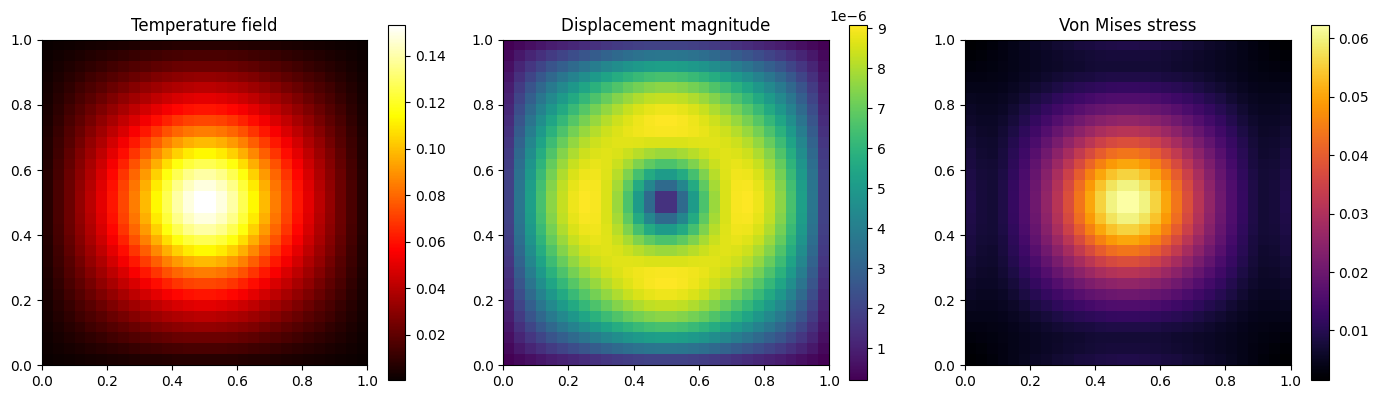

In [5]:
# Run the thermal solver for a centered heat source
thermal_out = apply_tesseract(
    thermal,
    {
        "source_x": jnp.float32(0.5),
        "source_y": jnp.float32(0.5),
        "source_intensity": jnp.float32(10.0),
        "source_width": np.float32(0.1),
        "displacement": jnp.zeros((30, 30, 2), dtype=jnp.float32),
        "conductivity": np.float32(1.0),
        "boundary_temp": np.float32(0.0),
    },
)
temperature = np.asarray(thermal_out["temperature"])

# Feed the temperature field into the structural solver
structural_out = apply_tesseract(
    structural,
    {
        "temperature": thermal_out["temperature"],
        "youngs_modulus": np.float32(200.0),
        "poissons_ratio": np.float32(0.3),
        "thermal_expansion": np.float32(1e-3),
    },
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im0 = axes[0].imshow(temperature.T, origin="lower", extent=[0, 1, 0, 1], cmap="hot")
axes[0].set_title("Temperature field")
plt.colorbar(im0, ax=axes[0])

disp_mag = np.linalg.norm(np.asarray(structural_out["displacement"]), axis=-1)
im1 = axes[1].imshow(disp_mag.T, origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
axes[1].set_title("Displacement magnitude")
plt.colorbar(im1, ax=axes[1])

s = np.asarray(structural_out["stress"])
von_mises = np.sqrt(
    s[:, :, 0] ** 2 - s[:, :, 0] * s[:, :, 1] + s[:, :, 1] ** 2 + 3 * s[:, :, 2] ** 2
)
im2 = axes[2].imshow(von_mises.T, origin="lower", extent=[0, 1, 0, 1], cmap="inferno")
axes[2].set_title("Von Mises stress")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## Step 3: Set up the thermoelastic inverse problem

Now we pose the inverse-design problem: **find the heat-source location and intensity that produce a set of target temperatures at four sensor locations, after the thermoelastic coupling has converged.**

This cannot be solved with the thermal solver alone. The displacement from thermal expansion deforms the geometry, which changes the temperature field, which changes the displacement, and so on. The two solvers must be iterated to a coupled equilibrium, and the gradients we need run through that entire iteration.

We express the coupled equilibrium as a fixed-point iteration with `jax.lax.scan`: at each step the thermal solver runs on the current displacement, and the structural solver runs on the resulting temperature. The design variables are the source position $(x, y)$ and the log-intensity $\log(q)$ (3 parameters), and the objective is the squared temperature error at the sensors:

$$\mathcal{L}(\theta) = \sum_i \left(T_{\text{sensor}_i} - T_{\text{target}_i}\right)^2,$$

evaluated after the coupling has converged.

In [6]:
# Sensor locations (grid indices) and target temperatures
SENSORS = [(8, 8), (8, 22), (22, 8), (22, 22)]
TARGETS = [jnp.float32(0.01), jnp.float32(0.02), jnp.float32(0.02), jnp.float32(0.05)]

# Approximate physical positions of sensors (for visualization)
sensor_positions = [(i / 31, j / 31) for i, j in SENSORS]
print("Sensor positions (approx):")
for (sx, sy), t in zip(sensor_positions, TARGETS, strict=False):
    print(f"  ({sx:.2f}, {sy:.2f}) -> T_target = {float(t):.3f}")

N_COUPLING_ITERS = 3


def coupled_objective(params):
    """Two-way coupled thermoelastic inverse problem.

    params: [source_x, source_y, log_intensity]
    Returns: sum of squared temperature errors at sensor locations.

    Non-differentiable constants are passed as numpy (np.float32) rather than
    JAX arrays. Inside lax.scan, JAX traces all array inputs uniformly and
    cannot tell which are constants; keeping them as numpy arrays leaves them
    opaque to the tracer, so the backward pass never tries to differentiate them.
    """
    source_x, source_y, log_intensity = params[0], params[1], params[2]
    intensity = jnp.exp(log_intensity)

    temp = jnp.zeros((30, 30), dtype=jnp.float32)
    disp = jnp.zeros((30, 30, 2), dtype=jnp.float32)

    def coupling_step(carry, _):
        _temp, disp = carry
        thermal_out = apply_tesseract(
            thermal,
            {
                "source_x": source_x,
                "source_y": source_y,
                "source_intensity": intensity,
                "source_width": np.float32(0.15),
                "displacement": disp,
                "conductivity": np.float32(1.0),
                "boundary_temp": np.float32(0.0),
            },
        )
        structural_out = apply_tesseract(
            structural,
            {
                "temperature": thermal_out["temperature"],
                "youngs_modulus": np.float32(200.0),
                "poissons_ratio": np.float32(0.3),
                "thermal_expansion": np.float32(1e-3),
            },
        )
        return (thermal_out["temperature"], structural_out["displacement"]), None

    (final_temp, _), _ = jax.lax.scan(
        coupling_step, (temp, disp), None, length=N_COUPLING_ITERS
    )

    loss = jnp.float32(0.0)
    for (si, sj), target in zip(SENSORS, TARGETS, strict=False):
        loss = loss + (final_temp[si, sj] - target) ** 2
    return loss


# Test the forward pass
p0 = jnp.array([0.2, 0.2, jnp.log(5.0)], dtype=jnp.float32)
print(f"\nObjective at initial guess: {float(coupled_objective(p0)):.6e}")

Sensor positions (approx):
  (0.26, 0.26) -> T_target = 0.010
  (0.26, 0.71) -> T_target = 0.020
  (0.71, 0.26) -> T_target = 0.020
  (0.71, 0.71) -> T_target = 0.050



Objective at initial guess: 6.175695e-03


## Step 4: Compute end-to-end gradients

Because `apply_tesseract` exposes each Tesseract as a native JAX operation, `jax.grad` differentiates through the entire coupled iteration -- through both solvers and through `lax.scan` -- automatically. There is no manual adjoint to derive and no need to merge the solvers into one codebase.

In [7]:
grad_fn = jax.grad(coupled_objective)

grads = grad_fn(p0)
print("Gradients at initial guess:")
print(f"  d(loss)/d(source_x)      = {float(grads[0]):.6e}")
print(f"  d(loss)/d(source_y)      = {float(grads[1]):.6e}")
print(f"  d(loss)/d(log_intensity) = {float(grads[2]):.6e}")

Gradients at initial guess:
  d(loss)/d(source_x)      = 2.295040e-02
  d(loss)/d(source_y)      = 2.295040e-02
  d(loss)/d(log_intensity) = 8.693030e-03


### Validate the gradients against finite differences

To confirm the end-to-end gradients are correct, we compare them against a central finite-difference approximation of the same objective. The relative error should be small for all three design variables.

In [8]:
eps = 1e-4
fd_grads = []
for i in range(3):
    p_plus = p0.at[i].add(eps)
    p_minus = p0.at[i].add(-eps)
    fd_grads.append(
        (coupled_objective(p_plus) - coupled_objective(p_minus)) / (2 * eps)
    )

names = ["d(loss)/d(source_x)", "d(loss)/d(source_y)", "d(loss)/d(log_intensity)"]
print(f"{'':32s} {'AD':>14s} {'FD':>14s} {'Rel. Error':>12s}")
for name, ad, fd in zip(names, grads, fd_grads, strict=False):
    rel_err = abs(float(ad) - float(fd)) / (abs(float(fd)) + 1e-30)
    print(f"{name:32s} {float(ad):14.6e} {float(fd):14.6e} {rel_err:12.2e}")

                                             AD             FD   Rel. Error
d(loss)/d(source_x)                2.295040e-02   2.296176e-02     4.95e-04
d(loss)/d(source_y)                2.295040e-02   2.295477e-02     1.90e-04
d(loss)/d(log_intensity)           8.693030e-03   8.677598e-03     1.78e-03


## Step 5: Optimize the design with gradients

We now solve the inverse problem with a gradient-based optimizer (L-BFGS-B from `scipy.optimize`), feeding it the end-to-end gradients we just validated. For comparison, we also run a gradient-free optimizer (Nelder-Mead) on the same problem. Both search over the same 3 design variables: source position $(x, y)$ and log-intensity.

In [9]:
eval_history_grad = []
eval_history_free = []


def objective_and_grad(x):
    p = jnp.array(x, dtype=jnp.float32)
    obj = coupled_objective(p)
    g = grad_fn(p)
    eval_history_grad.append(float(obj))
    return float(obj), np.array([float(g[i]) for i in range(3)])


def objective_only(x):
    p = jnp.array(x, dtype=jnp.float32)
    obj = coupled_objective(p)
    eval_history_free.append(float(obj))
    return float(obj)


x0 = np.array([0.2, 0.2, np.log(5.0)])
bounds = [(0.05, 0.95), (0.05, 0.95), (np.log(1.0), np.log(50.0))]

print("Running L-BFGS-B (gradient-based)...")
result_grad = minimize(
    objective_and_grad,
    x0,
    method="L-BFGS-B",
    jac=True,
    bounds=bounds,
    options={"maxiter": 100},
)
print(f"  Source: ({result_grad.x[0]:.3f}, {result_grad.x[1]:.3f})")
print(f"  Intensity: {np.exp(result_grad.x[2]):.2f}")
print(f"  Objective: {result_grad.fun:.6e}")
print(f"  Evaluations: {len(eval_history_grad)}")

print("\nRunning Nelder-Mead (gradient-free)...")
result_free = minimize(
    objective_only,
    x0,
    method="Nelder-Mead",
    options={"maxiter": 500, "xatol": 1e-6, "fatol": 1e-15},
)
print(f"  Source: ({result_free.x[0]:.3f}, {result_free.x[1]:.3f})")
print(f"  Intensity: {np.exp(result_free.x[2]):.2f}")
print(f"  Objective: {result_free.fun:.6e}")
print(f"  Evaluations: {len(eval_history_free)}")

print(
    f"\nSpeedup: {len(eval_history_free)}/{len(eval_history_grad)} "
    f"= {len(eval_history_free) / max(len(eval_history_grad), 1):.1f}x fewer evaluations with gradients"
)

Running L-BFGS-B (gradient-based)...


  Source: (0.673, 0.673)
  Intensity: 2.73
  Objective: 3.168823e-06
  Evaluations: 29

Running Nelder-Mead (gradient-free)...


  Source: (0.673, 0.673)
  Intensity: 2.73
  Objective: 3.168773e-06
  Evaluations: 250

Speedup: 250/29 = 8.6x fewer evaluations with gradients


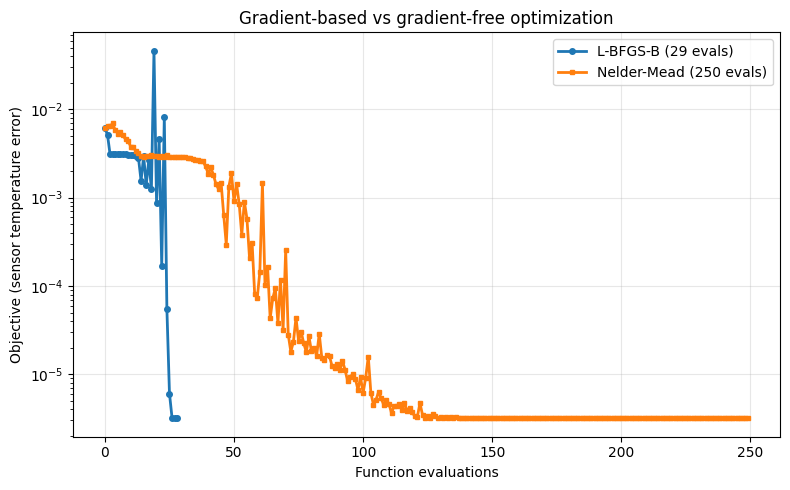

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(
    eval_history_grad,
    "o-",
    label=f"L-BFGS-B ({len(eval_history_grad)} evals)",
    linewidth=2,
    markersize=4,
)
ax.semilogy(
    eval_history_free,
    "s-",
    label=f"Nelder-Mead ({len(eval_history_free)} evals)",
    linewidth=2,
    markersize=3,
)
ax.set_xlabel("Function evaluations")
ax.set_ylabel("Objective (sensor temperature error)")
ax.set_title("Gradient-based vs gradient-free optimization")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Visualize the optimized design

Finally, we run the optimized design through the thermal solver once more and plot the resulting temperature field, overlaying the sensor locations with their achieved and target temperatures and the recovered source position.

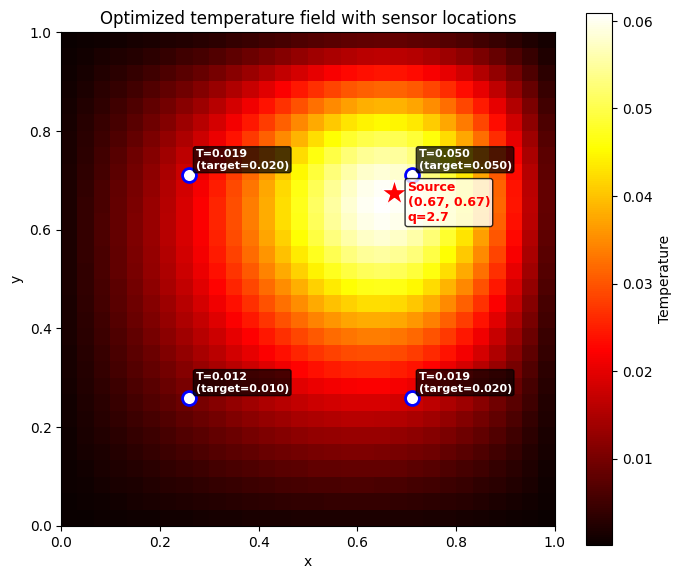

In [11]:
# Run the optimized design through the thermal solver
opt = result_grad.x
thermal_opt = apply_tesseract(
    thermal,
    {
        "source_x": jnp.float32(opt[0]),
        "source_y": jnp.float32(opt[1]),
        "source_intensity": jnp.float32(np.exp(opt[2])),
        "source_width": np.float32(0.15),
        "displacement": jnp.zeros((30, 30, 2), dtype=jnp.float32),
        "conductivity": np.float32(1.0),
        "boundary_temp": np.float32(0.0),
    },
)
temp_opt = np.asarray(thermal_opt["temperature"])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(temp_opt.T, origin="lower", extent=[0, 1, 0, 1], cmap="hot")
plt.colorbar(im, ax=ax, label="Temperature")

# Plot sensor locations and achieved vs target temperatures
for (si, sj), target in zip(SENSORS, TARGETS, strict=False):
    px, py = si / 31, sj / 31
    achieved = float(temp_opt[si, sj])
    ax.plot(px, py, "wo", markersize=10, markeredgecolor="blue", markeredgewidth=2)
    ax.annotate(
        f"T={achieved:.3f}\n(target={float(target):.3f})",
        xy=(px, py),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color="white",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7),
    )

# Plot optimized source location
ax.plot(
    float(opt[0]),
    float(opt[1]),
    "r*",
    markersize=20,
    markeredgecolor="white",
    markeredgewidth=1,
)
ax.annotate(
    f"Source\n({float(opt[0]):.2f}, {float(opt[1]):.2f})\nq={float(np.exp(opt[2])):.1f}",
    xy=(float(opt[0]), float(opt[1])),
    xytext=(10, -20),
    textcoords="offset points",
    fontsize=9,
    color="red",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
)

ax.set_title("Optimized temperature field with sensor locations")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## Step 7: Constant-memory gradients with implicit differentiation

The unrolled `lax.scan` above stores every intermediate state for backpropagation, so memory grows as $\mathcal{O}(N)$ in the number of coupling iterations. For large problems -- fine meshes, many iterations -- that becomes the bottleneck.

*Implicit differentiation* avoids it. At the converged fixed point $(T^*, D^*) = G(T^*, D^*, \theta)$, the implicit function theorem gives the sensitivity without replaying the iteration: the backward pass solves a single linear system instead of backpropagating through $N$ steps.

Concretely, if $v = \partial \mathcal{L} / \partial (T^*, D^*)$ is the loss gradient with respect to the fixed point, then

$$\lambda = \left(I - \partial G / \partial (T, D)\right)^{-T} v, \qquad \partial \mathcal{L} / \partial \theta = \lambda^\top \, \partial G / \partial \theta.$$

We solve for $\lambda$ by fixed-point iteration on the adjoint equation -- the same structure as the forward solve, but linear. We wrap this in a `jax.custom_vjp` so that `jax.grad` uses the implicit backward pass automatically, while the forward pass still composes the two Tesseracts through `apply_tesseract`.

In [12]:
def coupled_objective_implicit(params):
    """Same inverse problem, but differentiated via the implicit function theorem.

    Forward pass: iterate G to convergence (no scan intermediates stored for AD).
    Backward pass: solve adjoint equation (I - dG/d(T,D))^T λ = v via fixed-point iteration.
    """
    source_x, source_y, log_intensity = params[0], params[1], params[2]
    intensity = jnp.exp(log_intensity)

    def G(temp_disp, params_inner):
        """One coupling step: (temp, disp) -> (new_temp, new_disp).

        params_inner is (source_x, source_y, intensity) — the differentiable parameters.
        """
        _temp, disp = temp_disp
        sx, sy, q = params_inner
        thermal_out = apply_tesseract(
            thermal,
            {
                "source_x": sx,
                "source_y": sy,
                "source_intensity": q,
                "source_width": np.float32(0.15),
                "displacement": disp,
                "conductivity": np.float32(1.0),
                "boundary_temp": np.float32(0.0),
            },
        )
        structural_out = apply_tesseract(
            structural,
            {
                "temperature": thermal_out["temperature"],
                "youngs_modulus": np.float32(200.0),
                "poissons_ratio": np.float32(0.3),
                "thermal_expansion": np.float32(1e-3),
            },
        )
        return (thermal_out["temperature"], structural_out["displacement"])

    @jax.custom_vjp
    def solve_fixed_point(params_inner):
        """Run fixed-point iteration to convergence, return the fixed point."""
        temp = jnp.zeros((30, 30), dtype=jnp.float32)
        disp = jnp.zeros((30, 30, 2), dtype=jnp.float32)

        def step(carry, _):
            return G(carry, params_inner), None

        (final_temp, final_disp), _ = jax.lax.scan(
            step, (temp, disp), None, length=N_COUPLING_ITERS
        )
        return (final_temp, final_disp)

    def solve_fwd(params_inner):
        fixed_point = solve_fixed_point(params_inner)
        # Save fixed point and params for backward pass (NOT intermediates)
        return fixed_point, (fixed_point, params_inner)

    def solve_bwd(res, g):
        """Implicit differentiation backward pass.

        g = (v_temp, v_disp) — cotangents w.r.t. the fixed point.

        We need to solve: (I - dG/d(T,D))^T λ = v  for λ,
        then compute: dL/dθ = λ^T · dG/dθ.

        We solve for λ by iterating: λ_{k+1} = v + (dG/d(T,D))^T λ_k.
        This converges if the forward iteration is contractive.
        """
        (fixed_temp, fixed_disp), params_inner = res
        v_temp, v_disp = g

        # Define G_state: maps (temp, disp) -> (new_temp, new_disp) at fixed params
        def G_state(temp_disp):
            return G(temp_disp, params_inner)

        # Solve adjoint: λ = v + (dG/d(T,D))^T λ  via fixed-point iteration
        def adjoint_step(lam, _):
            lam_temp, lam_disp = lam
            # Compute (dG/d(T,D))^T @ λ via VJP
            _, vjp_G_state = jax.vjp(G_state, (fixed_temp, fixed_disp))
            dGT_lam = vjp_G_state((lam_temp, lam_disp))[0]
            # λ_{k+1} = v + (dG/d(T,D))^T λ_k
            new_lam_temp = v_temp + dGT_lam[0]
            new_lam_disp = v_disp + dGT_lam[1]
            return (new_lam_temp, new_lam_disp), None

        N_ADJOINT_ITERS = 20  # typically converges faster than forward
        lam_init = (v_temp, v_disp)
        (lam_temp, lam_disp), _ = jax.lax.scan(
            adjoint_step, lam_init, None, length=N_ADJOINT_ITERS
        )

        # Now compute dL/dθ = λ^T · dG/dθ via VJP of G w.r.t. params
        def G_params(p):
            return G((fixed_temp, fixed_disp), p)

        _, vjp_G_params = jax.vjp(G_params, params_inner)
        grad_params = vjp_G_params((lam_temp, lam_disp))[0]
        return (grad_params,)

    solve_fixed_point.defvjp(solve_fwd, solve_bwd)

    # --- Use the implicit fixed-point solve ---
    final_temp, _final_disp = solve_fixed_point((source_x, source_y, intensity))

    loss = jnp.float32(0.0)
    for (si, sj), target in zip(SENSORS, TARGETS, strict=False):
        loss = loss + (final_temp[si, sj] - target) ** 2
    return loss


# Verify forward pass matches the unrolled version
loss_implicit = coupled_objective_implicit(p0)
loss_unrolled = coupled_objective(p0)
print("Forward pass comparison:")
print(f"  Unrolled: {float(loss_unrolled):.10e}")
print(f"  Implicit: {float(loss_implicit):.10e}")
print(f"  Match: {jnp.allclose(loss_unrolled, loss_implicit)}")

Forward pass comparison:
  Unrolled: 6.1756954528e-03
  Implicit: 6.1756954528e-03
  Match: True


In [13]:
# Compare gradients: implicit vs unrolled vs finite differences
grad_implicit = jax.grad(coupled_objective_implicit)(p0)
grad_unrolled = jax.grad(coupled_objective)(p0)

# Finite differences as ground truth
eps = 1e-4
fd_grads_check = []
for i in range(3):
    p_plus = p0.at[i].add(eps)
    p_minus = p0.at[i].add(-eps)
    fd_grads_check.append(
        (coupled_objective_implicit(p_plus) - coupled_objective_implicit(p_minus))
        / (2 * eps)
    )

names = ["d(loss)/d(source_x)", "d(loss)/d(source_y)", "d(loss)/d(log_intensity)"]
print(f"{'':32s} {'Unrolled':>14s} {'Implicit':>14s} {'FD':>14s} {'Impl vs FD':>12s}")
for name, u, im, fd in zip(
    names, grad_unrolled, grad_implicit, fd_grads_check, strict=False
):
    rel_err = abs(float(im) - float(fd)) / (abs(float(fd)) + 1e-30)
    print(
        f"{name:32s} {float(u):14.6e} {float(im):14.6e} {float(fd):14.6e} {rel_err:12.2e}"
    )

                                       Unrolled       Implicit             FD   Impl vs FD
d(loss)/d(source_x)                2.295040e-02   2.295042e-02   2.296176e-02     4.94e-04
d(loss)/d(source_y)                2.295040e-02   2.295042e-02   2.295477e-02     1.90e-04
d(loss)/d(log_intensity)           8.693030e-03   8.693032e-03   8.677598e-03     1.78e-03


### Why this matters: memory scaling

With the unrolled approach, JAX stores the full state at every coupling iteration for backpropagation, so memory scales as $\mathcal{O}(N \times \text{state size})$.

With implicit differentiation, the forward pass runs to convergence and discards the intermediates; the backward pass solves the adjoint equation at the fixed point only, with no replay of the iteration. Memory scales as $\mathcal{O}(\text{state size})$, independent of $N$.

For this 30×30 demo the difference is negligible, but for production-scale problems -- large meshes and many coupling iterations -- it is what keeps the backward pass within the available memory.

## Takeaways

In this tutorial, we composed two independent physics Tesseracts into a two-way coupled pipeline and solved a thermoelastic inverse-design problem with end-to-end gradients. The key points:

1. **Independent solvers, composed.** The thermal and structural solvers are separate Tesseracts -- separate `tesseract_api.py`, separate container, separate dependencies. Tesseract-JAX wires them into one differentiable pipeline with `apply_tesseract`, no monolithic rewrite required.

2. **Gradients through two-way coupling.** The coupled equilibrium is a `jax.lax.scan` over alternating solver calls. Because each Tesseract exposes its derivatives, `jax.grad` propagates gradients through the entire iteration automatically, and the result matches finite differences.

3. **Gradients make optimization tractable.** Using the end-to-end gradients, L-BFGS-B solves the inverse problem in far fewer evaluations than the gradient-free Nelder-Mead baseline.

4. **Implicit differentiation for scale.** Wrapping the coupled solve in a `jax.custom_vjp` and solving the adjoint equation at the fixed point gives constant-memory gradients -- $\mathcal{O}(1)$ in coupling iterations instead of $\mathcal{O}(N)$ -- without changing the forward composition.

5. **The pattern generalizes.** Wrap each physics component as a Tesseract, compose with `apply_tesseract`, and differentiate with JAX. The same recipe applies to any multi-component, multi-physics differentiable pipeline.

### What's next

- **Add more physics.** Introduce a third coupled solver (e.g. a fluid or electromagnetic field) and let the gradients flow through all of them.
- **Scale up.** Increase the mesh resolution and the number of coupling iterations, and run the Tesseracts on a GPU.
- **Swap an implementation.** Because the pipeline composes Tesseracts by reference, you can replace a solver with a different image -- a higher-fidelity model or a learned surrogate -- without touching the optimization code.
- **Explore other demos.** See the [shape optimization](fem-shape-optimization.ipynb) and [data assimilation](data-assimilation.ipynb) demos for other ways to compose Tesseracts with JAX.

Questions? Feedback? Please reach out through the [Tesseract Community Forum](https://si-tesseract.discourse.group/).

In [14]:
# Shut down the Tesseract servers
thermal.teardown()
structural.teardown()